# Import librerie e creazione DataFrame

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import folium

In [52]:
df = pd.read_csv('dati_tesi_finali.csv', sep=',', encoding='UTF-8')

# Ottimizzazione dati

1. Correzione colonna date

In [53]:
df['data_record_start_time'] = pd.to_datetime(df['data_record_start_time'])
df['data_record_end_time'] = pd.to_datetime(df['data_record_end_time'])
print('Le colonne con date sono ora il tipo di dato corretto')

Le colonne con date sono ora il tipo di dato corretto


2. Analisi dati mancanti ed eventuale eliminazione righe con dati mancanti

   Rilevamenti totali  Rilevamenti mancanti
0             5287856                     0 



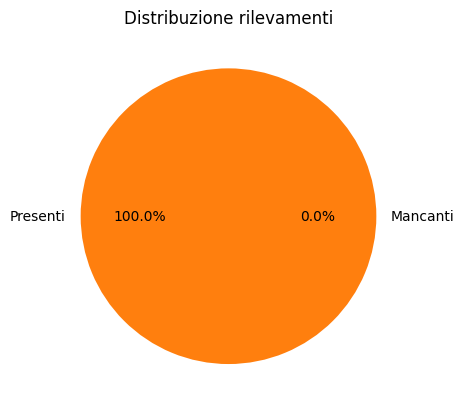

In [54]:
rilevamenti_mancanti = (df['data_record_value'].isna().sum())
rilevamenti_presenti = (df['data_record_value'].notna().sum())
rilevamenti_totali = len(df['data_record_value'])
percentuale_rilevamenti_mancanti = (rilevamenti_mancanti / rilevamenti_totali * 100).round(1)
percentuale_rilevamenti_presenti = (rilevamenti_presenti / rilevamenti_totali * 100).round(1)

riepilogo_mancanti = pd.DataFrame({
    'Rilevamenti totali': [rilevamenti_totali],
    'Rilevamenti mancanti': [rilevamenti_mancanti]
})

print(riepilogo_mancanti, '\n')

valori = [percentuale_rilevamenti_mancanti, percentuale_rilevamenti_presenti]
etichette = ['Mancanti', 'Presenti']

plt.pie(valori, labels=etichette, autopct='%1.1f%%')

plt.title("Distribuzione rilevamenti")
plt.show()

In [55]:
# df = df.dropna()
# print('Togliendo le righe con almeno una colonna nulla le righe del sono ora:', len(df))

3. Check valori in primary_observation_notation

In [56]:
df['primary_observation_notation'].value_counts()

primary_observation_notation
0 days 01:00:00    5287856
Name: count, dtype: int64

# Descrizione DF

In [57]:
df

,region_name,municipality_name,station_municipality,station_name,station_eu_code,station_id,station_position,station_lat,station_lon,station_altitude,...,data_record_end_time,data_record_value,observation_unit_notation,pollutant_notation,pollutant_label,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),wind_speed_10m (km/h),wind_direction_10m (°)
0,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-01 02:00:00,200.0,µg/m3,CO,Carbon monoxide (air),8.4,86,0.0,7.2,72
1,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-01 05:00:00,300.0,µg/m3,CO,Carbon monoxide (air),8.6,82,0.0,8.8,81
2,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-01 18:00:00,200.0,µg/m3,CO,Carbon monoxide (air),12.4,81,0.0,8.6,147
3,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-01 23:00:00,300.0,µg/m3,CO,Carbon monoxide (air),11.0,70,0.0,3.6,135
4,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-02 00:00:00,200.0,µg/m3,CO,Carbon monoxide (air),10.7,73,0.0,3.3,174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5287851,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,597,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,...,2025-12-30 03:00:00,13.0,µg/m3,O3,Ozone (air),0.6,87,0.0,4.3,66
5287852,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,597,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,...,2025-12-30 08:00:00,10.4,µg/m3,O3,Ozone (air),-1.2,83,0.0,3.2,117
5287853,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,597,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,...,2025-12-30 10:00:00,55.6,µg/m3,O3,Ozone (air),3.1,63,0.0,1.5,76
5287854,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,597,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,...,2025-12-31 00:00:00,30.2,µg/m3,O3,Ozone (air),0.4,61,0.0,3.8,73


In [58]:
df.info()

print('\n')

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5287856 entries, 0 to 5287855
Data columns (total 22 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   region_name                   str           
 1   municipality_name             str           
 2   station_municipality          str           
 3   station_name                  str           
 4   station_eu_code               str           
 5   station_id                    int64         
 6   station_position              str           
 7   station_lat                   float64       
 8   station_lon                   float64       
 9   station_altitude              float64       
 10  primary_observation_notation  str           
 11  data_record_start_time        datetime64[us]
 12  data_record_end_time          datetime64[us]
 13  data_record_value             float64       
 14  observation_unit_notation     str           
 15  pollutant_notation            str          

,station_id,station_lat,station_lon,station_altitude,data_record_start_time,data_record_end_time,data_record_value,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),wind_speed_10m (km/h),wind_direction_10m (°)
count,5.287856e+06,5.287856e+06,5.287856e+06,5.287856e+06,5287856,5287856,5.287856e+06,5.287856e+06,5.287856e+06,5.287856e+06,5.287856e+06,5.287856e+06
mean,2.937175e+02,4.335154e+01,1.200647e+01,1.900117e+02,2025-07-09 22:16:25.560874,2025-07-09 23:16:25.560874,6.943852e+01,1.802834e+01,6.992454e+01,9.954225e-02,7.418843e+00,1.778310e+02
min,0.000000e+00,3.550280e+01,6.835900e+00,-2.000000e+00,2025-01-01 00:00:00,2025-01-01 01:00:00,-1.410000e+02,-1.320000e+01,7.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.430000e+02,4.145389e+01,9.556389e+00,2.800000e+01,2025-05-06 03:00:00,2025-05-06 04:00:00,6.000000e+00,1.260000e+01,5.600000e+01,0.000000e+00,3.600000e+00,7.900000e+01
50%,2.920000e+02,4.394083e+01,1.181765e+01,1.000000e+02,2025-07-13 02:00:00,2025-07-13 03:00:00,1.660000e+01,1.810000e+01,7.200000e+01,0.000000e+00,5.900000e+00,1.800000e+02
75%,4.510000e+02,4.550472e+01,1.403333e+01,2.430000e+02,2025-09-12 04:00:00,2025-09-12 05:00:00,5.200000e+01,2.350000e+01,8.500000e+01,0.000000e+00,9.700000e+00,2.700000e+02
max,5.970000e+02,4.679735e+01,1.817667e+01,1.770000e+03,2025-12-31 23:00:00,2026-01-01 00:00:00,5.100000e+04,4.160000e+01,1.000000e+02,9.340000e+01,6.980000e+01,3.600000e+02
std,1.723565e+02,2.443796e+00,2.836634e+00,2.603529e+02,NaN,NaN,2.958891e+02,7.508249e+00,1.829094e+01,8.483456e-01,5.461166e+00,1.073304e+02


# Analisi rilevamento per comune

I comuni sono: 402 



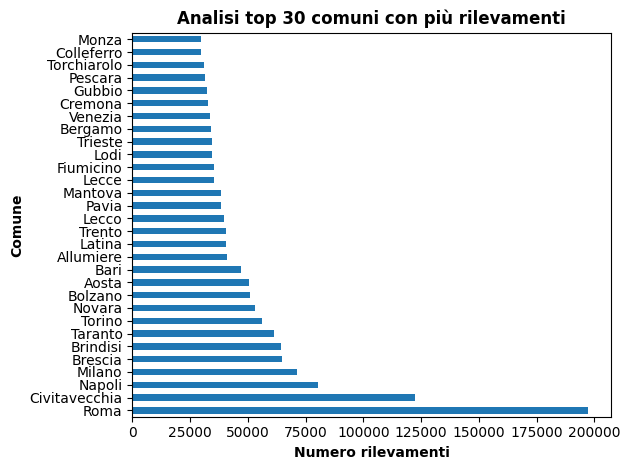

In [59]:
comuni = (df['municipality_name'].value_counts())

print('I comuni sono:', len(comuni), '\n')

top_comuni = comuni.head(30) 
#print(comuni, top_comuni)

top_comuni.plot(kind='barh')
plt.title('Analisi top 30 comuni con più rilevamenti', fontweight = 'bold')
plt.ylabel('Comune', fontweight = 'bold')
plt.xlabel('Numero rilevamenti', fontweight = 'bold')
plt.tight_layout()
plt.show()

# Analisi rilevamento per stazione

Le stazioni sono: 586 



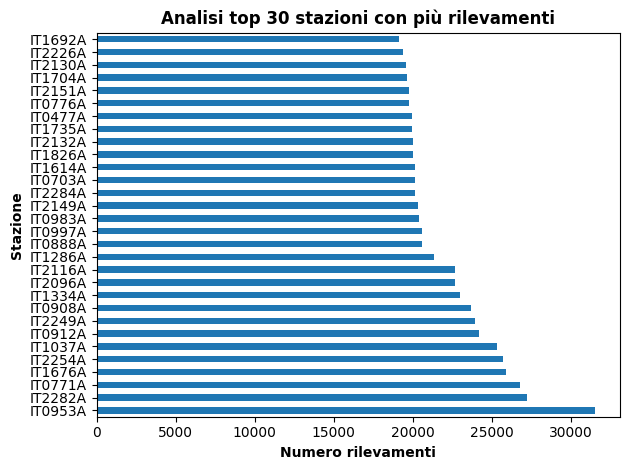

In [60]:
stazioni = (df['station_eu_code'].value_counts())

print('Le stazioni sono:', len(stazioni), '\n')
#print(stazioni, '\n')

top_stazioni = stazioni.head(30) 

top_stazioni.plot(kind='barh')
plt.title('Analisi top 30 stazioni con più rilevamenti', fontweight = 'bold')
plt.ylabel('Stazione', fontweight = 'bold')
plt.xlabel('Numero rilevamenti', fontweight = 'bold')
plt.tight_layout()
plt.show()

# Analisi posizioni geografiche

In [61]:
stazioni = (
    df[["station_id", "station_lat", "station_lon", "station_altitude"]]
    .drop_duplicates(subset="station_id")
    .reset_index(drop=True)
)

m = folium.Map(location=[41.5, 13.5], zoom_start=6, tiles="OpenStreetMap")

for _, r in stazioni.iterrows():
    folium.CircleMarker(
        location=[r["station_lat"], r["station_lon"]],
        radius=6,
        color="white",
        weight=1,
        fill=True,
        fill_color="#378ADD",
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Stazione {int(r['station_id'])}</b><br>"
            f"lat: {r['station_lat']:.4f}<br>"
            f"lon: {r['station_lon']:.4f}<br>"
            f"alt: {r['station_altitude']:.0f} m",
            max_width=180
        )
    ).add_to(m)

# m.save("mappa_tutte_stazioni.html")
m

# Analisi orizzonte temporale dei rilevamenti


 I rilevamenti iniziano nella data: 2025-01-01 00:00:00 
 I rilevamenti terminano nella data: 2026-01-01 00:00:00 
 I rilevamenti coprono un orizzonte temporale di: 365 days 00:00:00 



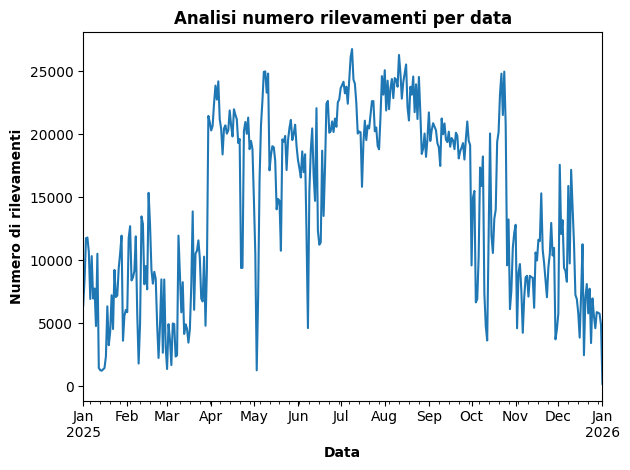

In [62]:
#print('Analisi data inizio rilevamento', '\n', df['data_record_start_time'].describe(), '\n')
#print('Analisi data fine rilevamento', '\n', df['data_record_end_time'].describe())

durata_totale = (max(df['data_record_end_time']) - min(df['data_record_start_time']))
#print(durata_totale)

print('\n', 'I rilevamenti iniziano nella data:', min(df['data_record_start_time']), '\n',
      'I rilevamenti terminano nella data:', max(df['data_record_end_time']), '\n',
      'I rilevamenti coprono un orizzonte temporale di:', durata_totale, '\n')


# # Grafico start time
# start_rilevamenti = df.set_index('data_record_start_time').resample('D').size()
# start_rilevamenti.plot(kind='line')
# plt.xlabel("Data", fontweight = 'bold')
# plt.ylabel("Numero di rilevamenti", fontweight = 'bold')
# plt.title("Analisi numero di rilevamenti", fontweight = 'bold')
# plt.tight_layout()
# plt.show()

# Grafico end time
end_rilevamenti = df.set_index('data_record_end_time').resample('D').size()
end_rilevamenti.plot(kind='line')
plt.xlabel("Data", fontweight = 'bold')
plt.ylabel("Numero di rilevamenti", fontweight = 'bold')
plt.title("Analisi numero rilevamenti per data", fontweight = 'bold')
plt.tight_layout()
plt.show()

# Analisi agenti e rilevamenti

1. Analisi numero agenti e tipo

Gli agenti sono: 6 



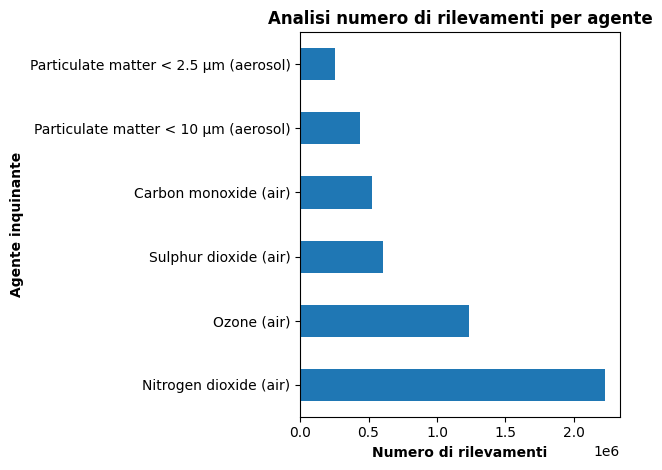

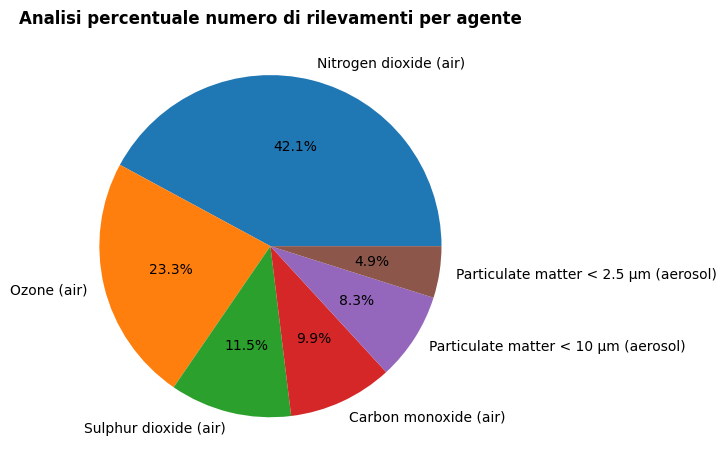

In [63]:
agenti = (df['pollutant_label'].value_counts())
print('Gli agenti sono:', len(agenti), '\n')

agenti.plot(kind='barh')
plt.ylabel('Agente inquinante', fontweight ='bold')
plt.xlabel('Numero di rilevamenti', fontweight = 'bold')
plt.title('Analisi numero di rilevamenti per agente', fontweight = 'bold')
plt.tight_layout()
plt.show()

print('\n')

agenti.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.xlabel('')
plt.title('Analisi percentuale numero di rilevamenti per agente', fontweight = 'bold')
plt.tight_layout()
plt.show()

2. Analisi valori di rilevamento

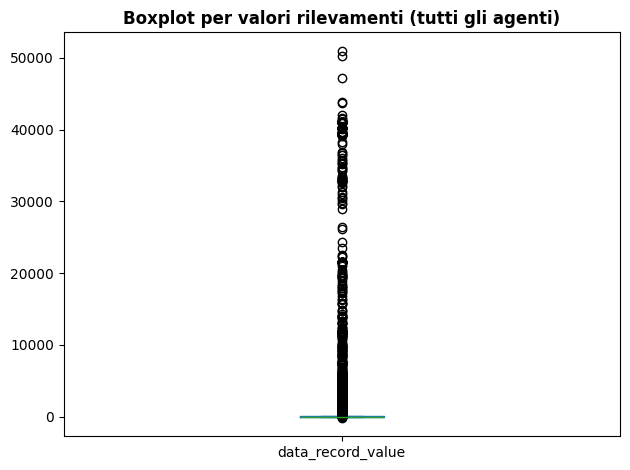

count    5.287856e+06
mean     6.943852e+01
std      2.958891e+02
min     -1.410000e+02
25%      6.000000e+00
50%      1.660000e+01
75%      5.200000e+01
max      5.100000e+04
Name: data_record_value, dtype: float64

In [64]:
rilevamenti = (df['data_record_value'])
#print(rilevamenti, '\n')
#print(df['pollutant_notation'].value_counts())

rilevamenti.plot(kind='box')
plt.title('Boxplot per valori rilevamenti (tutti gli agenti)', fontweight='bold')
plt.tight_layout()
plt.show()

rilevamenti.describe()


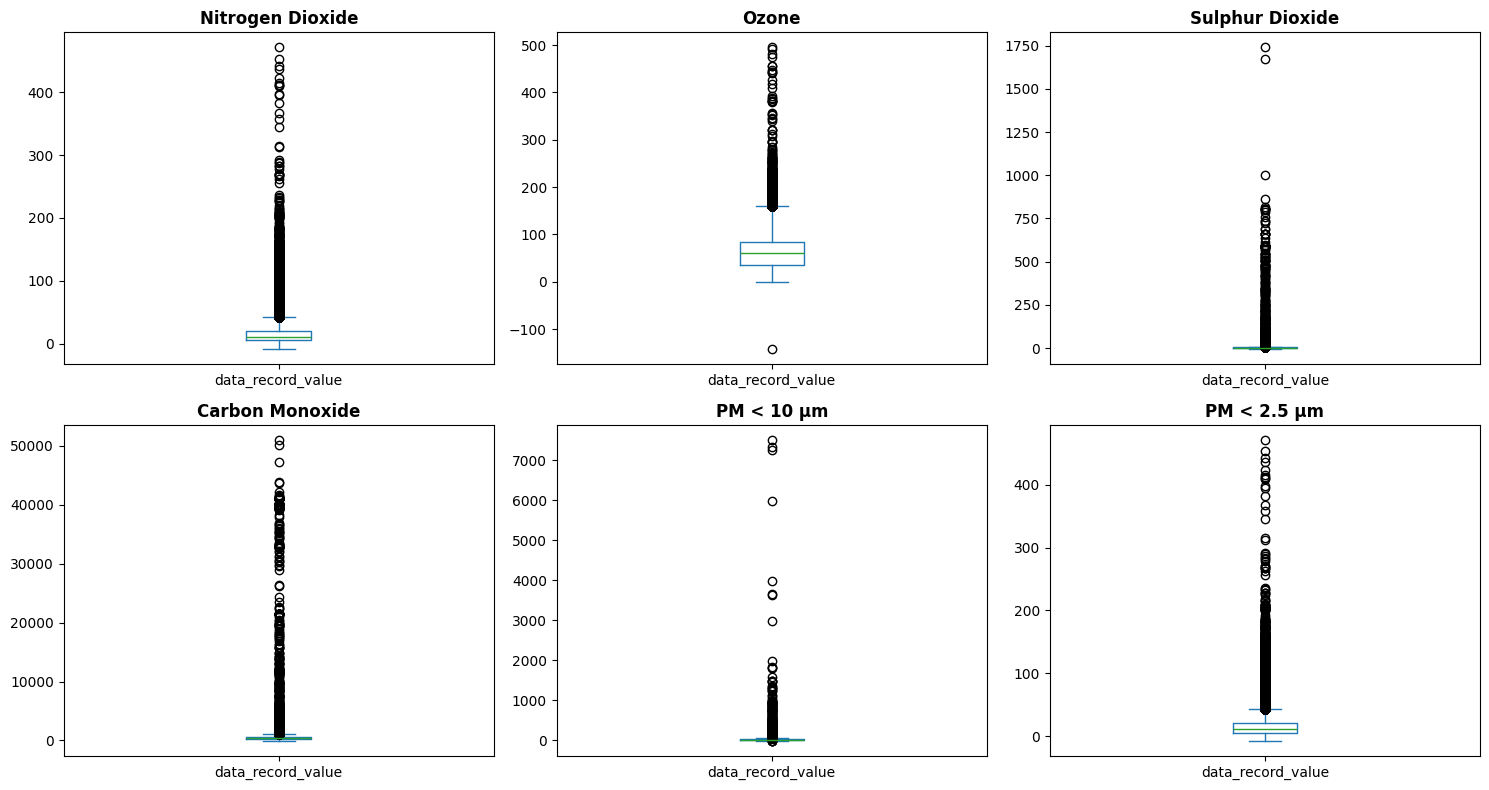

,mean,std,min,max,count
pollutant_label,,,,,
Nitrogen dioxide (air),15.384700,13.538922,-7.51420,471.00,2226799
Ozone (air),61.748710,34.856473,-141.00000,495.00,1233127
Sulphur dioxide (air),3.011292,8.565816,-3.29476,1740.00,608333
Carbon monoxide (air),462.193109,838.625962,-100.00000,51000.00,523173
Particulate matter < 10 µm (aerosol),20.134657,31.313149,-17.00000,7503.53,438587
Particulate matter < 2.5 µm (aerosol),16.710647,58.421905,-20.00000,985.00,257837


In [65]:
no2 = df[df['pollutant_notation'] == 'NO2']
o3 = df[df['pollutant_notation'] == 'O3']
so2 = df[df['pollutant_notation'] == 'SO2']
co = df[df['pollutant_notation'] == 'CO']
pm10 = df[df['pollutant_notation'] == 'PM10']
pm25 = df[df['pollutant_notation'] == 'NO2']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

datasets = [
    (no2, 'Nitrogen Dioxide'),
    (o3, 'Ozone'),
    (so2, 'Sulphur Dioxide'),
    (co, 'Carbon Monoxide'),
    (pm10, 'PM < 10 µm'),
    (pm25, 'PM < 2.5 µm')
]

for ax, (dataset, title) in zip(axes, datasets):
    dataset['data_record_value'].plot(
        kind='box',
        ax=ax
    )
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

df.groupby('pollutant_label')['data_record_value'].agg(['mean', 'std', 'min', 'max', 'count']).sort_values(by='count', ascending=False)

3. Gestione outlier

In [66]:
# SO2
max_outlier = so2[so2['data_record_value'] == max(so2['data_record_value'])]
# max_outlier

so2 = so2.drop(max_outlier.index)
df = df.drop(max_outlier.index)
print("Il primo outlier più grande per SO2 è stato eliminato")

max_outlier = so2[so2['data_record_value'] == max(so2['data_record_value'])]
# max_outlier

so2 = so2.drop(max_outlier.index)
df = df.drop(max_outlier.index)
print("Il secondo outlier più grande per SO2 è stato eliminato")

max_outlier = so2[so2['data_record_value'] == max(so2['data_record_value'])]
# max_outlier

so2 = so2.drop(max_outlier.index)
df = df.drop(max_outlier.index)
print("Il terzo outlier più grande per SO2 è stato eliminato")


Il primo outlier più grande per SO2 è stato eliminato
Il secondo outlier più grande per SO2 è stato eliminato
Il terzo outlier più grande per SO2 è stato eliminato


In [67]:
# PM10
max_outlier = pm10[pm10['data_record_value'] > 2500]
# max_outlier

pm10 = pm10.drop(max_outlier.index)
df = df.drop(max_outlier.index)
print('Tutti gli outlier maggiori di 2500 µg/m3 per PM10 sono stati eliminati')

Tutti gli outlier maggiori di 2500 µg/m3 per PM10 sono stati eliminati


In [72]:
# Outlier negativi
outlier_negativi = df[df['data_record_value'] < 0]
# outlier_negativi

df.loc[outlier_negativi.index, 'data_record_value'] = 0
print('Tutti gli outlier negativi sono stati eliminati')

Tutti gli outlier negativi sono stati eliminati


4. Analisi valori di rilevamento senza outlier

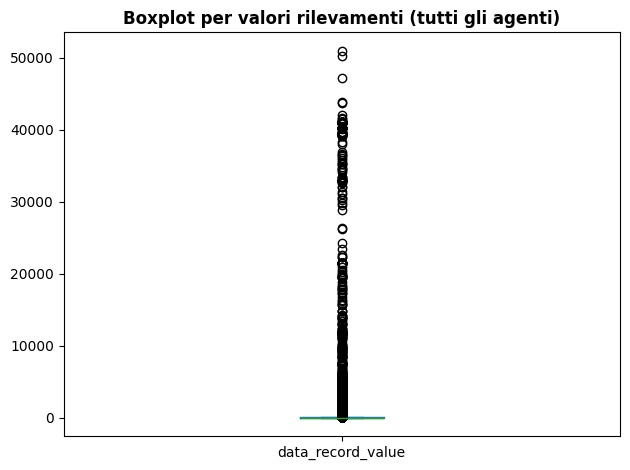

count    5.287845e+06
mean     6.943036e+01
std      2.958094e+02
min      0.000000e+00
25%      6.000000e+00
50%      1.660000e+01
75%      5.200000e+01
max      5.100000e+04
Name: data_record_value, dtype: float64

In [69]:
rilevamenti = (df['data_record_value'])
#print(rilevamenti, '\n')
#print(df['pollutant_notation'].value_counts())

rilevamenti.plot(kind='box')
plt.title('Boxplot per valori rilevamenti (tutti gli agenti)', fontweight='bold')
plt.tight_layout()
plt.show()

rilevamenti.describe()

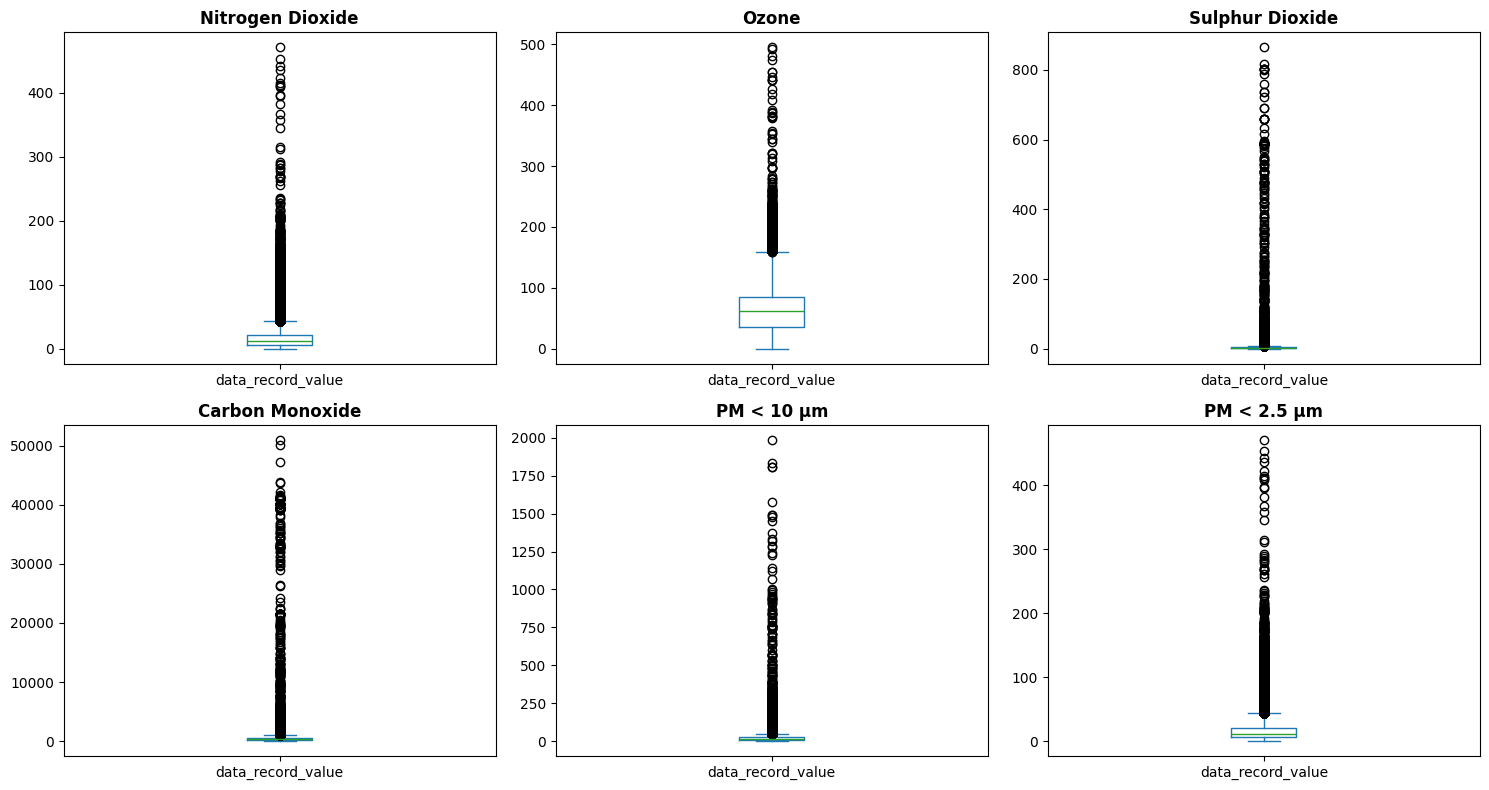

,mean,std,min,max,count
pollutant_label,,,,,
Nitrogen dioxide (air),15.384729,13.538884,0.0,471.0000,2226799
Ozone (air),61.748824,34.856039,0.0,495.0000,1233127
Sulphur dioxide (air),3.004097,7.887431,0.0,864.7482,608330
Carbon monoxide (air),462.195777,838.624340,0.0,51000.0000,523173
Particulate matter < 10 µm (aerosol),20.039553,20.385589,0.0,1986.6500,438579
Particulate matter < 2.5 µm (aerosol),16.713659,58.420866,0.0,985.0000,257837


In [70]:
no2 = df[df['pollutant_notation'] == 'NO2']
o3 = df[df['pollutant_notation'] == 'O3']
so2 = df[df['pollutant_notation'] == 'SO2']
co = df[df['pollutant_notation'] == 'CO']
pm10 = df[df['pollutant_notation'] == 'PM10']
pm25 = df[df['pollutant_notation'] == 'NO2']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

datasets = [
    (no2, 'Nitrogen Dioxide'),
    (o3, 'Ozone'),
    (so2, 'Sulphur Dioxide'),
    (co, 'Carbon Monoxide'),
    (pm10, 'PM < 10 µm'),
    (pm25, 'PM < 2.5 µm')
]

for ax, (dataset, title) in zip(axes, datasets):
    dataset['data_record_value'].plot(
        kind='box',
        ax=ax
    )
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

df.groupby('pollutant_label')['data_record_value'].agg(['mean', 'std', 'min', 'max', 'count']).sort_values(by='count', ascending=False)

# Salvataggio DF per addestramento modelli

In [ ]:
# df.to_csv('dati_tesi_finali_addestramento.csv', index=False)